In [ ]:
import numpy as np
import pandas as pd
import scipy.io
import math
import os
import ntpath
import sys
import logging
import time
import sys

from importlib import reload
import plotly.graph_objects as go

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import SGD, Adam
#from keras.utils import np_utils
from keras.layers import LSTM, Embedding, RepeatVector, TimeDistributed, Masking, GRU
from keras.callbacks import EarlyStopping, ModelCheckpoint, LambdaCallback

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf

# Function to load a model and make predictions
def load_and_predict(model_path, X_test):
        
    model = tf.keras.models.load_model(model_path)
    predictions = model.predict(X_test)
    return predictions


# Function to calculate and print metrics
def calculate_and_print_metrics(y_test, predictions):
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    

    print("Mean Squared Error (MSE):", mse)
    print("R-squared (R2):", r2)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("Mean Absolute Error (MAE):", mae)
    

# Function to plot true vs predicted values
def plot_true_vs_predicted(y_test, predictions, model_name):
    plt.figure(figsize=(10, 6))
    plt.plot(y_test, label='True Values')
    plt.plot(predictions, label='Predicted Values')
    plt.xlabel('Data Points')
    plt.ylabel('Values')
    plt.legend()
    plt.title(f'True vs Predicted Values - Model: {model_name}')
    plt.show()


In [4]:
import numpy as np
import pandas as pd
import logging
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta

DATA_PATH = 'LG_HG2_Original_Dataset_McMasterUniversity_Jan_2020//'

class LgData():
    def __init__(self, base_path="./"):
        self.path = base_path + DATA_PATH
        self.logger = logging.getLogger()

    def get_discharge_whole_cycle(self, train_names, test_names, output_capacity=False, scale_test=False, output_time=False):
        train = self._get_data(train_names, output_capacity, output_time)
        test = self._get_data(test_names, output_capacity, output_time)
        train, test = self._scale_x(train, test, scale_test=scale_test)        
        return (train, test)
        
    def _get_data(self, names, output_capacity, output_time=False):
        cycles = []
        for name in names:
            cycle = pd.read_csv(self.path + name + '.csv', skiprows=30)
            cycle.columns = ['Time Stamp','Step','Status','Prog Time','Step Time','Cycle',
                            'Cycle Level','Procedure','Voltage','Current','Temperature','Capacity','WhAccu','Cnt','Empty']
            cycle = cycle[(cycle["Status"] == "TABLE") | (cycle["Status"] == "DCH")]

            max_discharge = abs(min(cycle["Capacity"]))
            cycle["SoC Capacity"] = max_discharge + cycle["Capacity"]
            cycle["SoC Percentage"] = cycle["SoC Capacity"] / max(cycle["SoC Capacity"])
            x = cycle[["Voltage", "Current", "Temperature"]].to_numpy()

            if output_time:
                cycle['Prog Time'] = cycle['Prog Time'].apply(self._time_string_to_seconds)
                cycle['Time in Seconds'] = cycle['Prog Time'] - cycle['Prog Time'][0]

            if output_capacity:
                if output_time:
                    y = cycle[["SoC Capacity", "Time in Seconds"]].to_numpy()
                else:
                    y = cycle[["SoC Capacity"]].to_numpy()
            else:
                if output_time:
                    y = cycle[["SoC Percentage", "Time in Seconds"]].to_numpy()
                else:
                    y = cycle[["SoC Percentage"]].to_numpy()

            if np.isnan(np.min(x)) or np.isnan(np.min(y)):
                self.logger.info("There is a NaN in cycle " + name + ", removing row")
                x = x[~np.isnan(x).any(axis=1)]
                y = y[~np.isnan(y).any(axis=1)].reshape(-1, y.shape[1])

            cycles.append((x, y))

        return cycles

    def _time_string_to_seconds(self, input_string):
        time_parts = input_string.split(':')
        second_parts = time_parts[2].split('.')
        return timedelta(hours=int(time_parts[0]), 
            minutes=int(time_parts[1]), 
            seconds=int(second_parts[0]), 
            microseconds=int(second_parts[1])).total_seconds()

    def _scale_x(self, train, test, scale_test=False):
        for index_feature in range(len(train[0][0][0])):
            feature_min = min([min(cycle[0][:,index_feature]) for cycle in train])
            feature_max = max([max(cycle[0][:,index_feature]) for cycle in train])
            for i in range(len(train)):
                train[i][0][:,index_feature] = (train[i][0][:,index_feature]-feature_min)/(feature_max-feature_min)
            if scale_test:
                for i in range(len(test)):
                    test[i][0][:,index_feature] = (test[i][0][:,index_feature]-feature_min)/(feature_max-feature_min)

        return train, test


    #################################
    #
    # get_stateful_cycle
    #
    #################################
    def get_stateful_cycle(self, cycles, pad_num = 0, steps = 100):
        max_lenght = max(max(len(cycle[0]) for cycle in cycles[0]), max(len(cycle[0]) for cycle in cycles[1]))
        train_x, train_y = self._to_padded_cycle(cycles[0], pad_num, max_lenght)
        test_x, test_y = self._to_padded_cycle(cycles[1], pad_num, max_lenght)
        train_x = self._split_cycle(train_x, steps)
        train_y = self._split_cycle(train_y, steps)
        test_x = self._split_cycle(test_x, steps)
        test_y = self._split_cycle(test_y, steps)
        self.logger.info("Train x: %s, train y: %s | Test x: %s, test y: %s" %
                         (train_x.shape, train_y.shape, test_x.shape, test_y.shape))
        return (train_x, train_y, test_x, test_y)

    def _to_padded_cycle(self, cycles, pad_num, max_lenght):
        x_length = len(cycles[0][0][0])
        y_length = len(cycles[0][1][0])
        x = np.full((len(cycles), max_lenght, x_length), pad_num, dtype=float)
        y = np.full((len(cycles), max_lenght, y_length), pad_num, dtype=float)
        for i, cycle in enumerate(cycles):
            x[i, :cycle[0].shape[0]] = cycle[0]
            y[i, :cycle[1].shape[0]] = cycle[1]
        return x, y

    def _split_cycle(self, cycles, steps):
        features = cycles.shape[2]
        time_steps = cycles.shape[1]
        new_cycles = np.empty((0, time_steps//steps, steps, features), float)
        for cycle in cycles:
            new_cycle = np.empty((0, steps, features), float)
            for i in range(0, len(cycle) - steps, steps):
                next_split = np.array(cycle[i:i + steps]).reshape(1, steps, features)
                new_cycle = np.concatenate((new_cycle, next_split))
            new_cycles = np.concatenate((new_cycles, new_cycle.reshape(1, time_steps//steps, steps, features)))
        return new_cycles


    #################################
    #
    # get_discharge_multiple_step
    #
    #################################
    def get_discharge_multiple_step(self, cycles, steps):
        train_x, train_y = self._split_to_multiple_step(cycles[0], steps)
        test_x, test_y = self._split_to_multiple_step(cycles[1], steps)
        self.logger.info("Train x: %s, train y: %s | Test x: %s, test y: %s" %
                         (train_x.shape, train_y.shape, test_x.shape, test_y.shape))
        return (train_x, train_y, test_x, test_y)

    def _split_to_multiple_step(self, cycles, steps):
        x_length = len(cycles[0][0][0])
        y_length = len(cycles[0][1][0])
        x = np.empty((0, steps, x_length), float)
        y = np.empty((0, steps, y_length), float)
        for cycle in cycles:
            for i in range(0, len(cycle[0]) - steps, steps):
                next_x = np.array(cycle[0][i:i + steps]).reshape(1, steps, x_length)
                next_y = np.array(cycle[1][i:i + steps]).reshape(1, steps, y_length)
                x = np.concatenate((x, next_x))
                y = np.concatenate((y, next_y))
        return x, y

    def keep_only_y_end(self, y, step, is_stateful=False):
        if is_stateful:
            return y[:,:,::step]
        else:
            return y[:,::step]


    

In [5]:
data_path = '/kaggle/input/battery-0-10-25/Battery_0_10_25/'
train_names = [
    '0degC/589_LA92',
    '0degC/589_Mixed1',
    '0degC/589_Mixed2',
    '0degC/589_UDDS',
    '0degC/589_US06',
    '0degC/590_Mixed7',
    '0degC/590_Mixed8',
    
    '10degC/582_LA92',
    '10degC/567_Mixed1',
    '10degC/567_Mixed2',
    '10degC/576_UDDS',
    '10degC/567_US06',
    '10degC/571_Mixed7',
    '10degC/571_Mixed8',
    
    '25degC/551_LA92', 
    '25degC/551_Mixed1', 
    '25degC/551_Mixed2', 
    '25degC/551_UDDS', 
    '25degC/551_US06', 
    '25degC/552_Mixed3',
    '25degC/552_Mixed7', 
    '25degC/552_Mixed8',   
    ]
test_names = [
    '0degC/590_Mixed4',
    '0degC/590_Mixed5',
    '0degC/590_Mixed6',
    
    '10degC/571_Mixed4',
    '10degC/571_Mixed5',
    '10degC/571_Mixed6',

    '25degC/552_Mixed4', 
    '25degC/552_Mixed5', 
    '25degC/552_Mixed6',
    ]

steps = 50

lg_data = LgData(data_path)
cycles = lg_data.get_discharge_whole_cycle(train_names, test_names, output_capacity=False, scale_test=True)
train_x, train_y, test_x, test_y = lg_data.get_discharge_multiple_step(cycles, steps)

train_y = lg_data.keep_only_y_end(train_y, steps)
test_y = lg_data.keep_only_y_end(test_y, steps)

In [6]:
test_x.shape

(11748, 50, 3)

# SELU

In [ ]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'selu'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

In [ ]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

In [10]:
#model.save('/kaggle/working/trained_model/%s.h5' % experiment_name)

hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


In [ ]:
model = tf.keras.models.load_model('/kaggle/working/results/trained_model/lstm_huber_50_steps_selu_best.h5')
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "SELU")

# Sigmoid

In [13]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'sigmoid'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_sigmoid
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 50, 256)           266240    
                                                                 
 lstm_3 (LSTM)               (None, 256)               525312    
                                                                 
 dense_3 (Dense)             (None, 256)               65792     
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________________

In [14]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000
54/54 - 10s - loss: 0.0417 - mse: 0.0834 - mae: 0.2500 - mape: 263.8421 - rmse: 0.2888 - val_loss: 0.0392 - val_mse: 0.0783 - val_mae: 0.2370 - val_mape: 321.6289 - val_rmse: 0.2798 - 10s/epoch - 192ms/step
Epoch 2/1000


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


54/54 - 6s - loss: 0.0413 - mse: 0.0825 - mae: 0.2491 - mape: 261.6518 - rmse: 0.2873 - val_loss: 0.0381 - val_mse: 0.0763 - val_mae: 0.2339 - val_mape: 312.2003 - val_rmse: 0.2762 - 6s/epoch - 113ms/step
Epoch 3/1000
54/54 - 6s - loss: 0.0321 - mse: 0.0642 - mae: 0.2129 - mape: 207.1246 - rmse: 0.2533 - val_loss: 0.0063 - val_mse: 0.0126 - val_mae: 0.0904 - val_mape: 125.9453 - val_rmse: 0.1123 - 6s/epoch - 114ms/step
Epoch 4/1000
54/54 - 6s - loss: 0.0071 - mse: 0.0142 - mae: 0.0940 - mape: 86.2883 - rmse: 0.1192 - val_loss: 0.0032 - val_mse: 0.0064 - val_mae: 0.0630 - val_mape: 73.7807 - val_rmse: 0.0801 - 6s/epoch - 114ms/step
Epoch 5/1000
54/54 - 6s - loss: 0.0047 - mse: 0.0094 - mae: 0.0765 - mape: 66.0480 - rmse: 0.0969 - val_loss: 0.0031 - val_mse: 0.0061 - val_mae: 0.0684 - val_mape: 74.2517 - val_rmse: 0.0783 - 6s/epoch - 117ms/step
Epoch 6/1000
54/54 - 6s - loss: 0.0039 - mse: 0.0079 - mae: 0.0699 - mape: 59.6015 - rmse: 0.0888 - val_loss: 0.0016 - val_mse: 0.0032 - val_mae:

In [15]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 37s 101ms/step
Mean Squared Error (MSE): 0.002329259097853514
R-squared (R2): 0.9703187679381684
Root Mean Squared Error (RMSE): 0.04826239838480382
Mean Absolute Error (MAE): 0.03741908625980889
Higher predictions : 5757
Lower predictions : 5991
In range predictions : 0
Ratio(Higher/Lower) : 0.9609414121181773


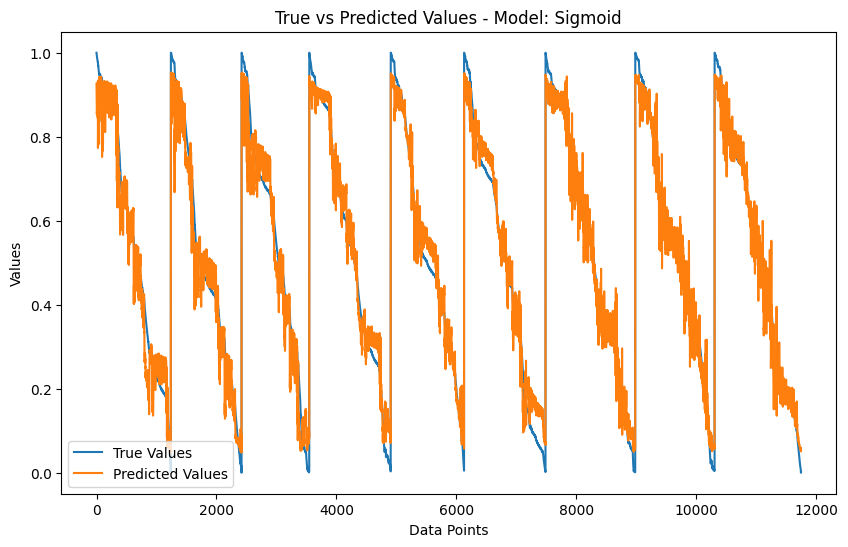

In [11]:
model = tf.keras.models.load_model('/kaggle/working/results/trained_model/lstm_huber_50_steps_sigmoid_best.h5')
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "Sigmoid")

# Tanh

In [7]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'tanh'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_tanh
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 256)           266240    
                                                                 
 lstm_1 (LSTM)               (None, 256)               525312    
                                                                 
 dense (Dense)               (None, 256)               65792     
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
_____________________________________________________________

In [8]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000


I0000 00:00:1708942192.637069      98 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 - 10s - loss: 0.0116 - mse: 0.0232 - mae: 0.0968 - mape: 81.6272 - rmse: 0.1525 - val_loss: 0.0012 - val_mse: 0.0023 - val_mae: 0.0375 - val_mape: 26.5539 - val_rmse: 0.0481 - 10s/epoch - 185ms/step
Epoch 2/1000


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


54/54 - 3s - loss: 0.0012 - mse: 0.0024 - mae: 0.0384 - mape: 24.8735 - rmse: 0.0494 - val_loss: 8.8406e-04 - val_mse: 0.0018 - val_mae: 0.0312 - val_mape: 25.2177 - val_rmse: 0.0420 - 3s/epoch - 49ms/step
Epoch 3/1000
54/54 - 3s - loss: 0.0011 - mse: 0.0023 - mae: 0.0369 - mape: 23.8450 - rmse: 0.0475 - val_loss: 7.2296e-04 - val_mse: 0.0014 - val_mae: 0.0291 - val_mape: 22.8350 - val_rmse: 0.0380 - 3s/epoch - 47ms/step
Epoch 4/1000
54/54 - 3s - loss: 0.0011 - mse: 0.0022 - mae: 0.0364 - mape: 23.6188 - rmse: 0.0466 - val_loss: 5.9130e-04 - val_mse: 0.0012 - val_mae: 0.0273 - val_mape: 21.0283 - val_rmse: 0.0344 - 3s/epoch - 47ms/step
Epoch 5/1000
54/54 - 2s - loss: 9.9363e-04 - mse: 0.0020 - mae: 0.0347 - mape: 22.7146 - rmse: 0.0446 - val_loss: 6.2749e-04 - val_mse: 0.0013 - val_mae: 0.0285 - val_mape: 18.0474 - val_rmse: 0.0354 - 2s/epoch - 46ms/step
Epoch 6/1000
54/54 - 3s - loss: 9.6944e-04 - mse: 0.0019 - mae: 0.0344 - mape: 21.5385 - rmse: 0.0440 - val_loss: 4.6545e-04 - val_ms

In [9]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 39s 103ms/step
Mean Squared Error (MSE): 0.0007723916357357739
R-squared (R2): 0.9901575846997795
Root Mean Squared Error (RMSE): 0.027791934724588244
Mean Absolute Error (MAE): 0.020343428152574144
Higher predictions : 5221
Lower predictions : 6527
In range predictions : 0
Ratio(Higher/Lower) : 0.7999080741535162


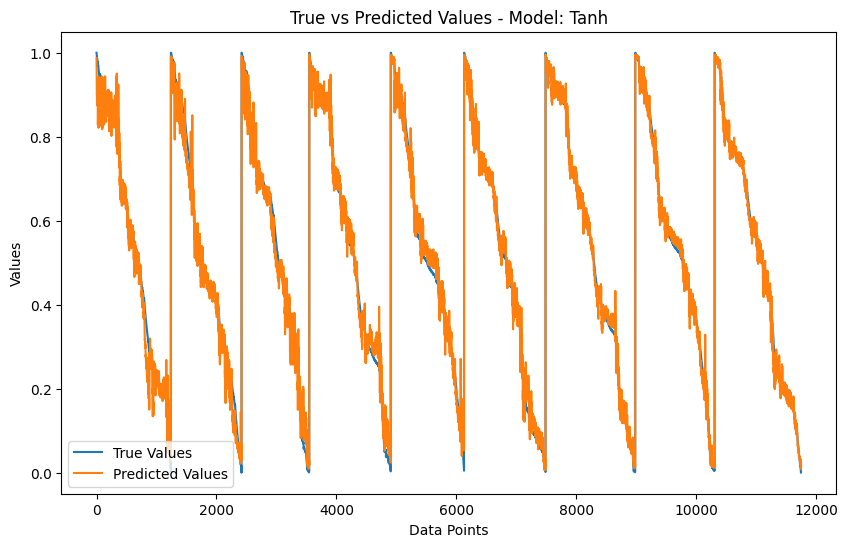

In [12]:
model = tf.keras.models.load_model('/kaggle/working/results/trained_model/lstm_huber_50_steps_tanh_best.h5')
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "Tanh")

# Mish

In [12]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'mish'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_mish
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 50, 256)           266240    
                                                                 
 lstm_5 (LSTM)               (None, 256)               525312    
                                                                 
 dense_6 (Dense)             (None, 256)               65792     
                                                                 
 dense_7 (Dense)             (None, 128)               32896     
                                                                 
 dense_8 (Dense)             (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
___________________________________________________________

In [13]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000
54/54 - 11s - loss: 0.0344 - mse: 0.0688 - mae: 0.1889 - mape: 135.6192 - rmse: 0.2624 - val_loss: 8.8923e-04 - val_mse: 0.0018 - val_mae: 0.0358 - val_mape: 21.6891 - val_rmse: 0.0422 - 11s/epoch - 207ms/step
Epoch 2/1000
54/54 - 7s - loss: 0.0017 - mse: 0.0033 - mae: 0.0433 - mape: 30.1998 - rmse: 0.0575 - val_loss: 8.5614e-04 - val_mse: 0.0017 - val_mae: 0.0303 - val_mape: 38.2189 - val_rmse: 0.0414 - 7s/epoch - 129ms/step
Epoch 3/1000
54/54 - 7s - loss: 0.0012 - mse: 0.0024 - mae: 0.0374 - mape: 26.6010 - rmse: 0.0494 - val_loss: 9.6387e-04 - val_mse: 0.0019 - val_mae: 0.0318 - val_mape: 37.2088 - val_rmse: 0.0439 - 7s/epoch - 129ms/step
Epoch 4/1000
54/54 - 7s - loss: 0.0012 - mse: 0.0023 - mae: 0.0364 - mape: 25.9678 - rmse: 0.0481 - val_loss: 9.1497e-04 - val_mse: 0.0018 - val_mae: 0.0317 - val_mape: 34.2487 - val_rmse: 0.0428 - 7s/epoch - 127ms/step
Epoch 5/1000
54/54 - 7s - loss: 0.0011 - mse: 0.0022 - mae: 0.0359 - mape: 25.8690 - rmse: 0.0474 - val_loss: 8.0421e

In [14]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 43s 115ms/step
Mean Squared Error (MSE): 0.0009638607431643526
R-squared (R2): 0.9877177363310443
Root Mean Squared Error (RMSE): 0.031046106731188575
Mean Absolute Error (MAE): 0.02419568619032653
Higher predictions : 6860
Lower predictions : 4888
In range predictions : 0
Ratio(Higher/Lower) : 1.4034369885433715


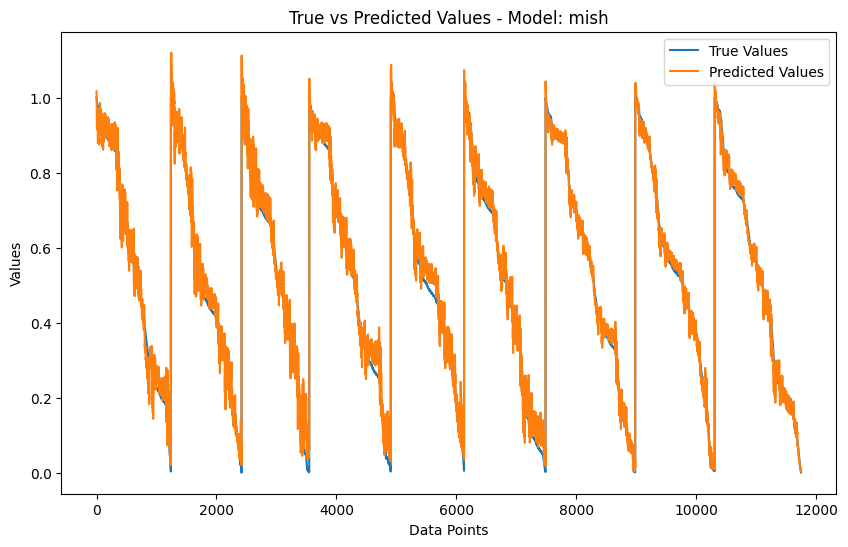

In [13]:
model = tf.keras.models.load_model("/kaggle/working/results/trained_model/lstm_huber_50_steps_mish_best.h5")
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, 'mish')

# Swish

In [16]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'swish'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_swish
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 50, 256)           266240    
                                                                 
 lstm_7 (LSTM)               (None, 256)               525312    
                                                                 
 dense_9 (Dense)             (None, 256)               65792     
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 dense_11 (Dense)            (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
__________________________________________________________

In [17]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000
54/54 - 11s - loss: 0.0466 - mse: 0.0931 - mae: 0.2353 - mape: 179.0442 - rmse: 0.3052 - val_loss: 0.0031 - val_mse: 0.0062 - val_mae: 0.0657 - val_mape: 71.4990 - val_rmse: 0.0785 - 11s/epoch - 203ms/step
Epoch 2/1000
54/54 - 7s - loss: 0.0029 - mse: 0.0058 - mae: 0.0564 - mape: 41.1438 - rmse: 0.0762 - val_loss: 7.8655e-04 - val_mse: 0.0016 - val_mae: 0.0303 - val_mape: 28.6207 - val_rmse: 0.0397 - 7s/epoch - 128ms/step
Epoch 3/1000
54/54 - 7s - loss: 0.0013 - mse: 0.0026 - mae: 0.0389 - mape: 26.6635 - rmse: 0.0514 - val_loss: 0.0010 - val_mse: 0.0020 - val_mae: 0.0331 - val_mape: 37.4321 - val_rmse: 0.0448 - 7s/epoch - 132ms/step
Epoch 4/1000
54/54 - 7s - loss: 0.0012 - mse: 0.0024 - mae: 0.0372 - mape: 25.9959 - rmse: 0.0491 - val_loss: 9.9500e-04 - val_mse: 0.0020 - val_mae: 0.0339 - val_mape: 39.3770 - val_rmse: 0.0446 - 7s/epoch - 132ms/step
Epoch 5/1000
54/54 - 7s - loss: 0.0011 - mse: 0.0023 - mae: 0.0361 - mape: 26.1343 - rmse: 0.0478 - val_loss: 8.4262e-04 - va

In [18]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 38s 104ms/step
Mean Squared Error (MSE): 0.0008457773916938919
R-squared (R2): 0.989222446288328
Root Mean Squared Error (RMSE): 0.029082252177125
Mean Absolute Error (MAE): 0.022194457602632552
Higher predictions : 5483
Lower predictions : 6265
In range predictions : 0
Ratio(Higher/Lower) : 0.8751795690343176


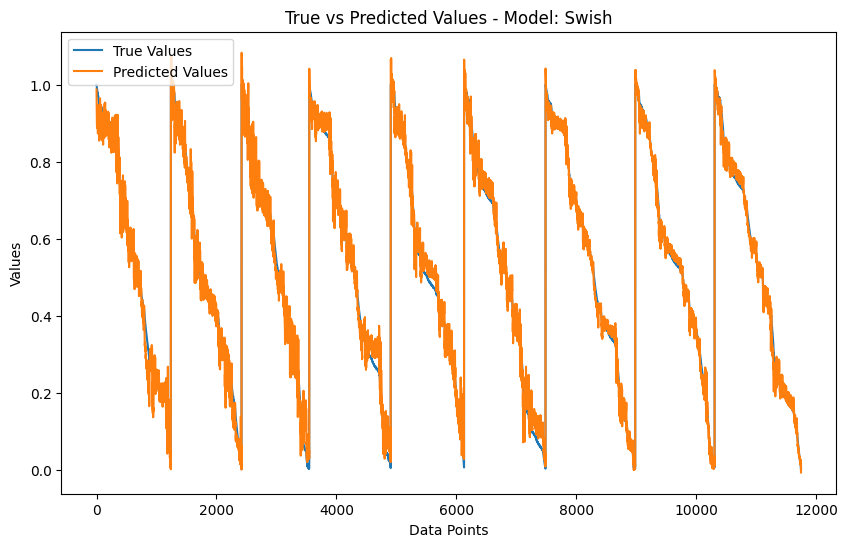

In [14]:
model = tf.keras.models.load_model("/kaggle/working/results/trained_model/lstm_huber_50_steps_swish_best.h5")
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "Swish")

# RELU

In [20]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'relu'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_relu
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 50, 256)           266240    
                                                                 
 lstm_9 (LSTM)               (None, 256)               525312    
                                                                 
 dense_12 (Dense)            (None, 256)               65792     
                                                                 
 dense_13 (Dense)            (None, 128)               32896     
                                                                 
 dense_14 (Dense)            (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
___________________________________________________________

In [21]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000
54/54 - 10s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val_mae: 0.4673 - val_mape: 100.0000 - val_rmse: 0.5406 - 10s/epoch - 178ms/step
Epoch 2/1000


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


54/54 - 6s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val_mae: 0.4673 - val_mape: 100.0000 - val_rmse: 0.5406 - 6s/epoch - 108ms/step
Epoch 3/1000
54/54 - 6s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val_mae: 0.4673 - val_mape: 100.0000 - val_rmse: 0.5406 - 6s/epoch - 110ms/step
Epoch 4/1000
54/54 - 6s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val_mae: 0.4673 - val_mape: 100.0000 - val_rmse: 0.5406 - 6s/epoch - 113ms/step
Epoch 5/1000
54/54 - 6s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val_mae: 0.4673 - val_mape: 100.0000 - val_rmse: 0.5406 - 6s/epoch - 109ms/step
Epoch 6/1000
54/54 - 6s - loss: 0.1871 - mse: 0.3742 - mae: 0.5402 - mape: 100.0000 - rmse: 0.6117 - val_loss: 0.1461 - val_mse: 0.2923 - val

In [22]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 37s 100ms/step
Mean Squared Error (MSE): 0.35621966173028863
R-squared (R2): -3.5392281410630657
Root Mean Squared Error (RMSE): 0.5968414041688869
Mean Absolute Error (MAE): 0.5270140788104121
Higher predictions : 0
Lower predictions : 11748
In range predictions : 0
Ratio(Higher/Lower) : 0.0


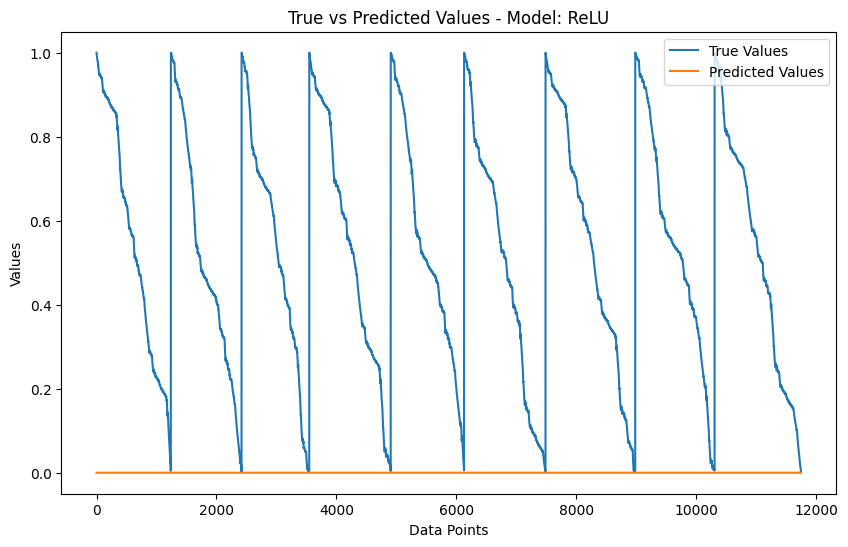

In [15]:
model = tf.keras.models.load_model("/kaggle/working/results/trained_model/lstm_huber_50_steps_relu_best.h5")
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "ReLU")

# Leaky Relu

In [24]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'leaky_relu'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_leaky_relu
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 50, 256)           266240    
                                                                 
 lstm_11 (LSTM)              (None, 256)               525312    
                                                                 
 dense_15 (Dense)            (None, 256)               65792     
                                                                 
 dense_16 (Dense)            (None, 128)               32896     
                                                                 
 dense_17 (Dense)            (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
_____________________________________________________

In [25]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000
54/54 - 10s - loss: 0.0150 - mse: 0.0301 - mae: 0.1091 - mape: 84.6438 - rmse: 0.1734 - val_loss: 4.0592e-04 - val_mse: 8.1184e-04 - val_mae: 0.0219 - val_mape: 14.6642 - val_rmse: 0.0285 - 10s/epoch - 180ms/step
Epoch 2/1000


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


54/54 - 6s - loss: 9.8935e-04 - mse: 0.0020 - mae: 0.0333 - mape: 22.5677 - rmse: 0.0445 - val_loss: 4.4035e-04 - val_mse: 8.8070e-04 - val_mae: 0.0229 - val_mape: 10.5871 - val_rmse: 0.0297 - 6s/epoch - 111ms/step
Epoch 3/1000
54/54 - 6s - loss: 7.9649e-04 - mse: 0.0016 - mae: 0.0305 - mape: 18.2855 - rmse: 0.0399 - val_loss: 5.8514e-04 - val_mse: 0.0012 - val_mae: 0.0242 - val_mape: 9.1616 - val_rmse: 0.0342 - 6s/epoch - 112ms/step
Epoch 4/1000
54/54 - 6s - loss: 6.8155e-04 - mse: 0.0014 - mae: 0.0283 - mape: 15.8481 - rmse: 0.0369 - val_loss: 3.8945e-04 - val_mse: 7.7890e-04 - val_mae: 0.0227 - val_mape: 9.8745 - val_rmse: 0.0279 - 6s/epoch - 111ms/step
Epoch 5/1000
54/54 - 6s - loss: 6.3967e-04 - mse: 0.0013 - mae: 0.0274 - mape: 15.0996 - rmse: 0.0358 - val_loss: 4.0642e-04 - val_mse: 8.1285e-04 - val_mae: 0.0203 - val_mape: 8.1250 - val_rmse: 0.0285 - 6s/epoch - 111ms/step
Epoch 6/1000
54/54 - 6s - loss: 7.1456e-04 - mse: 0.0014 - mae: 0.0292 - mape: 14.5670 - rmse: 0.0378 - val_

In [26]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 37s 100ms/step
Mean Squared Error (MSE): 0.0007369261561661016
R-squared (R2): 0.9906095134398075
Root Mean Squared Error (RMSE): 0.027146383850636564
Mean Absolute Error (MAE): 0.019855695451659917
Higher predictions : 6614
Lower predictions : 5134
In range predictions : 0
Ratio(Higher/Lower) : 1.28827425009739


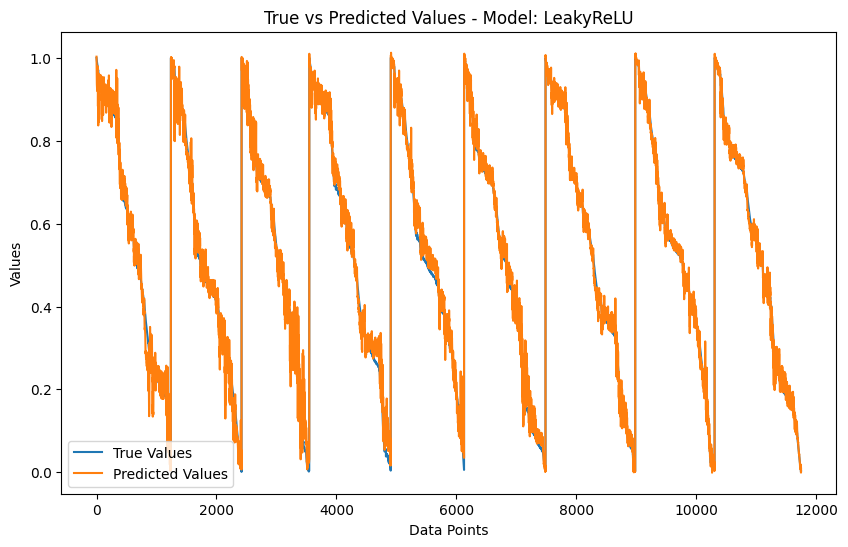

In [16]:
model = tf.keras.models.load_model("/kaggle/working/results/trained_model/lstm_huber_50_steps_leaky_relu_best.h5")
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, "LeakyReLU")

# ELU

In [8]:
EXPERIMENT = "lstm_huber_50_steps"
ACTIVATION = 'elu'
experiment_name =  EXPERIMENT + '_' + ACTIVATION
print(experiment_name)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    
# Model definition
opt = tf.keras.optimizers.Adam(lr=0.00001)

model = Sequential()
model.add(LSTM(256, activation=ACTIVATION,
                return_sequences=True,
                input_shape=(train_x.shape[1], train_x.shape[2])))
model.add(LSTM(256, activation=ACTIVATION, return_sequences=False))
model.add(Dense(256, activation=ACTIVATION))
model.add(Dense(128, activation=ACTIVATION))
model.add(Dense(1, activation=ACTIVATION))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=30)
model_path = '/kaggle/working/results/trained_model/%s_best.h5' % experiment_name
mc = ModelCheckpoint(model_path, 
                             save_best_only=True, 
                             monitor='val_loss')

lstm_huber_50_steps_elu
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 256)           266240    
                                                                 
 lstm_1 (LSTM)               (None, 256)               525312    
                                                                 
 dense (Dense)               (None, 256)               65792     
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 890369 (3.40 MB)
Trainable params: 890369 (3.40 MB)
Non-trainable params: 0 (0.00 Byte)
______________________________________________________________

In [9]:
history = model.fit(train_x, train_y, 
                                epochs=1000, 
                                batch_size=500, 
                                verbose=2,
                                validation_split=0.2,
                                callbacks = [es, mc]
                               )

Epoch 1/1000


I0000 00:00:1708838681.941750      80 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 - 12s - loss: 0.0101 - mse: 0.0201 - mae: 0.0886 - mape: 66.4170 - rmse: 0.1419 - val_loss: 9.4275e-04 - val_mse: 0.0019 - val_mae: 0.0320 - val_mape: 53.2115 - val_rmse: 0.0434 - 12s/epoch - 230ms/step
Epoch 2/1000


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


54/54 - 6s - loss: 0.0013 - mse: 0.0026 - mae: 0.0382 - mape: 31.2002 - rmse: 0.0510 - val_loss: 9.2508e-04 - val_mse: 0.0019 - val_mae: 0.0323 - val_mape: 36.9387 - val_rmse: 0.0430 - 6s/epoch - 115ms/step
Epoch 3/1000
54/54 - 6s - loss: 0.0012 - mse: 0.0024 - mae: 0.0370 - mape: 27.4494 - rmse: 0.0488 - val_loss: 9.2551e-04 - val_mse: 0.0019 - val_mae: 0.0332 - val_mape: 30.8221 - val_rmse: 0.0430 - 6s/epoch - 111ms/step
Epoch 4/1000
54/54 - 6s - loss: 0.0011 - mse: 0.0022 - mae: 0.0354 - mape: 26.4615 - rmse: 0.0465 - val_loss: 8.8005e-04 - val_mse: 0.0018 - val_mae: 0.0334 - val_mape: 39.0633 - val_rmse: 0.0420 - 6s/epoch - 112ms/step
Epoch 5/1000
54/54 - 6s - loss: 0.0011 - mse: 0.0023 - mae: 0.0368 - mape: 25.7642 - rmse: 0.0477 - val_loss: 4.6078e-04 - val_mse: 9.2157e-04 - val_mae: 0.0240 - val_mape: 31.6606 - val_rmse: 0.0304 - 6s/epoch - 112ms/step
Epoch 6/1000
54/54 - 6s - loss: 9.3727e-04 - mse: 0.0019 - mae: 0.0331 - mape: 23.0480 - rmse: 0.0433 - val_loss: 7.5008e-04 - va

In [10]:
hist_df = pd.DataFrame(history.history)
hist_csv_file = '/kaggle/working/results/trained_model/%s_history.csv' % experiment_name
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)
    print("Completed")

Completed


368/368 [==============================] - 38s 102ms/step
Mean Squared Error (MSE): 0.0009056150983007483
R-squared (R2): 0.9884599476648461
Root Mean Squared Error (RMSE): 0.03009343945614639
Mean Absolute Error (MAE): 0.022537535105820884
Higher predictions : 5203
Lower predictions : 6545
In range predictions : 0
Ratio(Higher/Lower) : 0.7949579831932773


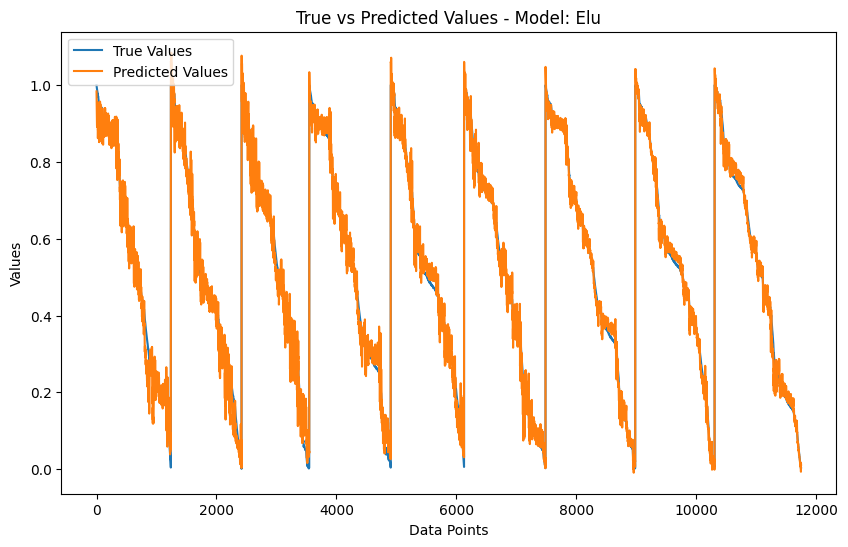

In [17]:
model = tf.keras.models.load_model("/kaggle/working/results/trained_model/lstm_huber_50_steps_elu_best.h5")
predictions = model.predict(test_x)

# Calculate and print metrics
calculate_and_print_metrics(test_y.reshape(-1,1), predictions)

# Plot true vs predicted values
plot_true_vs_predicted(test_y.reshape(-1,1), predictions, 'Elu')